In [72]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from radiomics import featureextractor
import SimpleITK as sitk

# Function to load NIfTI images 
def load_nifti_image(subject_dir, filename_pattern):
    file_list = glob.glob(os.path.join(subject_dir, filename_pattern))
    if len(file_list) == 0:
        raise FileNotFoundError(f"No files found matching {filename_pattern} in {subject_dir}")
    img = nib.load(file_list[0])
    return img.get_fdata()

# Preprocess image
def preprocess_image(image_data, target_size=(128, 128)):
    image_data = (image_data - np.min(image_data)) / (np.max(image_data) - np.min(image_data) + 1e-8)
    middle_slice = image_data[:, :, image_data.shape[2] // 2]
    return tf.image.resize(middle_slice[..., np.newaxis], target_size)

# Prepare data
def prepare_data(data_dir, target_size=(128, 128)):
    images, masks = [], []
    r0_dirs = glob.glob(os.path.join(data_dir, 'R0*/sub-*/ses-1/anat'))
    for img_dir in r0_dirs:
        try:
            img_data = load_nifti_image(img_dir, 'sub-*_T1w.nii.gz')
            img_preprocessed = preprocess_image(img_data, target_size)
            images.append(img_preprocessed.numpy())

            mask_data = load_nifti_image(img_dir, 'sub-*_label-L_desc-T1lesion_mask.nii.gz')
            mask_preprocessed = preprocess_image(mask_data, target_size)
            masks.append(mask_preprocessed.numpy())
        except FileNotFoundError:
            continue
    return np.array(images), np.array(masks)

# Load data
data_dir_train = '/Users/olayinkaajao/Downloads/ATLAS_2/Training'
X, y = prepare_data(data_dir_train)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Define U-Net model
def unet_model(input_shape=(128, 128, 1), regularized=False):
    inputs = layers.Input(input_shape)
    reg = regularizers.l2(1e-4) if regularized else None

    # Encoder
    conv1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(inputs)
    conv1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(conv1)
    pool1 = layers.MaxPooling2D((2, 2))(conv1)
    pool1 = layers.Dropout(0.3)(pool1) if regularized else pool1

    conv2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(pool1)
    conv2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(conv2)
    pool2 = layers.MaxPooling2D((2, 2))(conv2)
    pool2 = layers.Dropout(0.3)(pool2) if regularized else pool2

    # Bottleneck
    conv3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(pool2)
    conv3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(conv3)

    # Decoder
    up1 = layers.Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same', kernel_regularizer=reg)(conv3)
    up1 = layers.concatenate([up1, conv2])
    conv4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(up1)
    conv4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(conv4)

    up2 = layers.Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same', kernel_regularizer=reg)(conv4)
    up2 = layers.concatenate([up2, conv1])
    conv5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(up2)
    conv5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(conv5)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(conv5)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Train U-Net models
unet_regularized = unet_model(regularized=True)

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, mode='min', verbose=1, restore_best_weights=True)

# Train models
unet_regularized.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val), callbacks=[early_stopping])

# Predict masks using U-Net
predicted_masks = unet_regularized.predict(X_val)





Epoch 1/10
17/17 [==============================] - 41s 2s/step - loss: 0.3740 - accuracy: 0.9857 - val_loss: 0.1839 - val_accuracy: 0.9875
Epoch 2/10
17/17 [==============================] - 41s 2s/step - loss: 0.1484 - accuracy: 0.9874 - val_loss: 0.1364 - val_accuracy: 0.9875
Epoch 3/10
17/17 [==============================] - 41s 2s/step - loss: 0.1236 - accuracy: 0.9874 - val_loss: 0.1225 - val_accuracy: 0.9875
Epoch 4/10
17/17 [==============================] - 41s 2s/step - loss: 0.1144 - accuracy: 0.9874 - val_loss: 0.1200 - val_accuracy: 0.9875
Epoch 5/10
17/17 [==============================] - 41s 2s/step - loss: 0.1093 - accuracy: 0.9874 - val_loss: 0.1138 - val_accuracy: 0.9875
Epoch 6/10
17/17 [==============================] - 42s 2s/step - loss: 0.1045 - accuracy: 0.9874 - val_loss: 0.1100 - val_accuracy: 0.9875
Epoch 7/10
17/17 [==============================] - 41s 2s/step - loss: 0.1002 - accuracy: 0.9874 - val_loss: 0.1091 - val_accuracy: 0.9875
Epoch 8/10
17/17 [==

Epoch 1/30
33/33 [==============================] - 43s 1s/step - loss: 0.4234 - accuracy: 0.9772 - val_loss: 0.1226 - val_accuracy: 0.9875
Epoch 2/30
33/33 [==============================] - 41s 1s/step - loss: 0.1020 - accuracy: 0.9874 - val_loss: 0.0724 - val_accuracy: 0.9875
Epoch 3/30
33/33 [==============================] - 41s 1s/step - loss: 0.0627 - accuracy: 0.9874 - val_loss: 0.0726 - val_accuracy: 0.9875
Epoch 4/30
33/33 [==============================] - 41s 1s/step - loss: 0.0574 - accuracy: 0.9874 - val_loss: 0.0683 - val_accuracy: 0.9875
Epoch 5/30
33/33 [==============================] - 41s 1s/step - loss: 0.0562 - accuracy: 0.9874 - val_loss: 0.0699 - val_accuracy: 0.9875
Epoch 6/30
33/33 [==============================] - 41s 1s/step - loss: 0.0557 - accuracy: 0.9874 - val_loss: 0.0737 - val_accuracy: 0.9875
Epoch 7/30
33/33 [==============================] - 41s 1s/step - loss: 0.0560 - accuracy: 0.9874 - val_loss: 0.0694 - val_accuracy: 0.9875
Epoch 8/30
33/33 [==

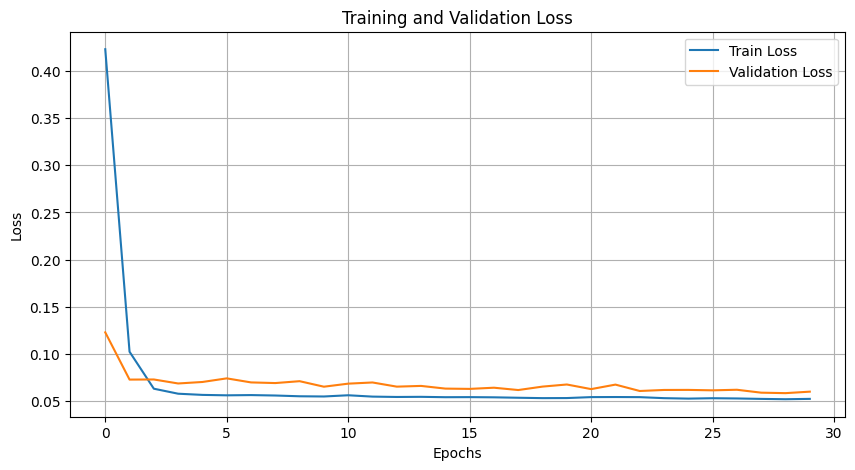

In [74]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import MeanIoU

# Weighted Binary Cross-Entropy Loss
def weighted_binary_crossentropy(weight):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)  # Ensure y_true is float32
        bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
        weight_map = tf.where(tf.equal(y_true, 1), tf.constant(weight, dtype=tf.float32), tf.constant(1.0, dtype=tf.float32))
        return tf.reduce_mean(bce * weight_map)
    return loss


# Define Improved U-Net Model
def improved_unet_model(input_shape=(128, 128, 1)):
    inputs = layers.Input(input_shape)

    # Encoder
    conv1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    conv1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(conv1)
    pool1 = layers.MaxPooling2D((2, 2))(conv1)
    pool1 = layers.Dropout(0.3)(pool1)

    conv2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(conv2)
    pool2 = layers.MaxPooling2D((2, 2))(conv2)
    pool2 = layers.Dropout(0.3)(pool2)

    # Bottleneck
    conv3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(conv3)

    # Decoder
    up1 = layers.Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same')(conv3)
    up1 = layers.concatenate([up1, conv2])
    conv4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(up1)
    conv4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(conv4)

    up2 = layers.Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same')(conv4)
    up2 = layers.concatenate([up2, conv1])
    conv5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(up2)
    conv5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(conv5)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(conv5)
    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=weighted_binary_crossentropy(weight=5),
        metrics=['accuracy']
    )
    return model

# Initialize the Model
improved_unet = improved_unet_model()

# Early Stopping Callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, mode='min', restore_best_weights=True)

# Train the Model
history = improved_unet.fit(
    X_train, y_train,
    epochs=30,
    validation_data=(X_val, y_val),
    batch_size=16,
    callbacks=[early_stopping]
)

# Plot Training and Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()






5/5 [==============================] - 0s 24ms/step


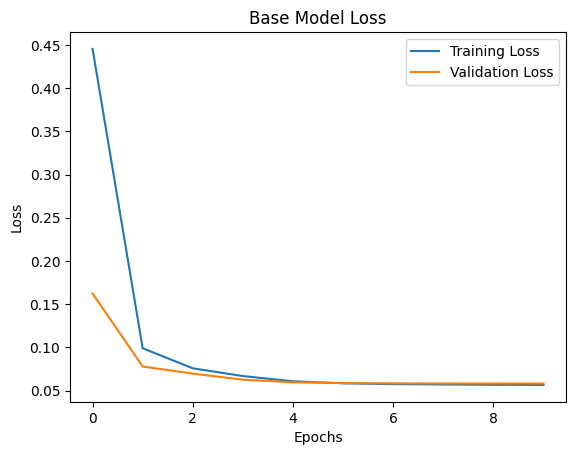

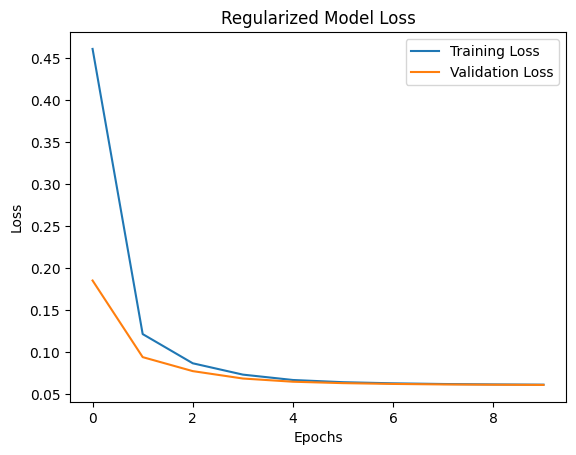

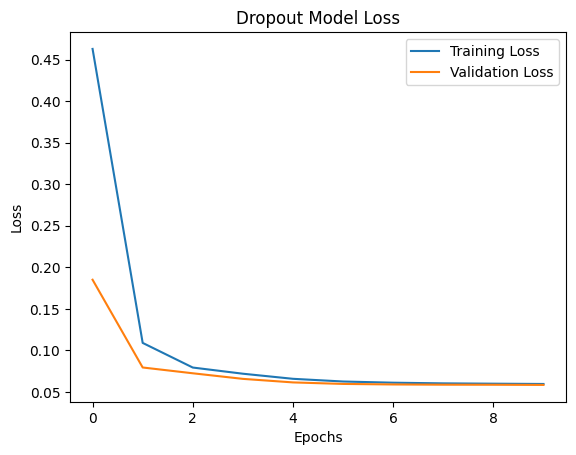

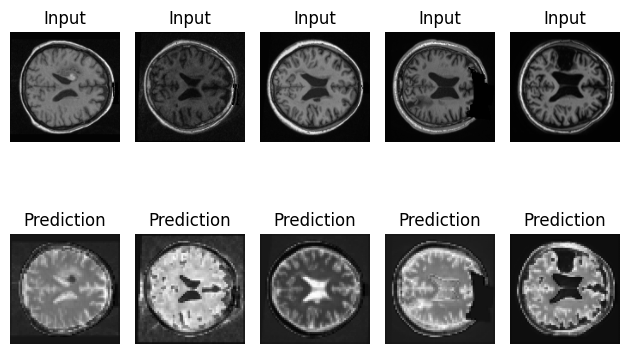


Model Performance Summary:
      Model  Train Loss  Validation Loss  Accuracy
       Base    0.056644         0.058274  0.988924
Regularized    0.061511         0.061209  0.988924
    Dropout    0.059619         0.058476  0.988924


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Conv2DTranspose, concatenate
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Define model variants
def create_models(input_shape=(128, 128, 1)):
    # Base model
    def build_base_model():
        inputs = Input(input_shape)
        c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
        p1 = MaxPooling2D((2, 2))(c1)
        u1 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(p1)
        outputs = Conv2D(1, (1, 1), activation='sigmoid')(u1)
        model = Model(inputs, outputs)
        model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
        return model

    # Regularized model (without dropout)
    def build_regularized_model():
        inputs = Input(input_shape)
        c1 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer='l2')(inputs)
        p1 = MaxPooling2D((2, 2))(c1)
        u1 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(p1)
        outputs = Conv2D(1, (1, 1), activation='sigmoid')(u1)
        model = Model(inputs, outputs)
        model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
        return model

    # Dropout model
    def build_dropout_model():
        inputs = Input(input_shape)
        c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
        p1 = MaxPooling2D((2, 2))(c1)
        d1 = Dropout(0.5)(p1)
        u1 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(d1)
        outputs = Conv2D(1, (1, 1), activation='sigmoid')(u1)
        model = Model(inputs, outputs)
        model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
        return model

    return build_base_model(), build_regularized_model(), build_dropout_model()



# Generate models
base_model, regularized_model, dropout_model = create_models()

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train models
# Train models
models_data = {}
for model_name, model in zip(['Base', 'Regularized', 'Dropout'], [base_model, regularized_model, dropout_model]):
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=16, callbacks=[early_stopping], verbose=0)
    predictions = model.predict(X_val)
    y_pred_binary = (predictions > 0.5).astype(int)
    y_val_binary = (y_val > 0.5).astype(int)  # Convert ground truth to binary
    metrics = {
        'train_loss': history.history['loss'][-1],
        'val_loss': history.history['val_loss'][-1],
        'accuracy': accuracy_score(y_val_binary.flatten(), y_pred_binary.flatten()),
        'precision': precision_score(y_val_binary.flatten(), y_pred_binary.flatten(), zero_division=0),
        'f1_score': f1_score(y_val_binary.flatten(), y_pred_binary.flatten(), zero_division=0)
    }
    models_data[model_name] = {'model': model, 'history': history, 'metrics': metrics, 'predictions': predictions}



# Plot training and validation loss
for model_name, data in models_data.items():
    history = data['history']
    plt.figure()
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# Display predictions
for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_val[i].squeeze(), cmap='gray')
    plt.title("Input")
    plt.axis('off')

    plt.subplot(2, 5, i + 6)
    plt.imshow(models_data['Base']['predictions'][i].squeeze(), cmap='gray')
    plt.title("Prediction")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Create summary table
summary_data = {
    "Model": [],
    "Train Loss": [],
    "Validation Loss": [],
  
    "Accuracy": []

}

for model_name, data in models_data.items():
    metrics = data['metrics']
    summary_data["Model"].append(model_name)
    summary_data["Train Loss"].append(metrics['train_loss'])
    summary_data["Validation Loss"].append(metrics['val_loss'])
    #summary_data["Precision"].append(metrics['precision'])
    summary_data["Accuracy"].append(metrics['accuracy'])
   # summary_data["F1 Score"].append(metrics['f1_score'])

# Convert summary data to a pandas DataFrame
summary_df = pd.DataFrame(summary_data)

# Print summary table
print("\nModel Performance Summary:")
print(summary_df.to_string(index=False))


# Display summary as a styled DataFrame
#import ace_tools as tools; tools.display_dataframe_to_user(name="Model Performance Summary", dataframe=summary_df)


Epoch 1/40
50/50 [==============================] - 116s 2s/step - loss: 0.5604 - accuracy: 0.9689 - val_loss: 0.5210 - val_accuracy: 0.9875
Epoch 2/40
50/50 [==============================] - 115s 2s/step - loss: 0.5196 - accuracy: 0.9874 - val_loss: 0.5197 - val_accuracy: 0.9875
Epoch 3/40
50/50 [==============================] - 116s 2s/step - loss: 0.5170 - accuracy: 0.9874 - val_loss: 0.5183 - val_accuracy: 0.9875
Epoch 4/40
50/50 [==============================] - 116s 2s/step - loss: 0.5158 - accuracy: 0.9874 - val_loss: 0.5128 - val_accuracy: 0.9875
Epoch 5/40
50/50 [==============================] - 1159s 24s/step - loss: 0.5126 - accuracy: 0.9874 - val_loss: 0.5081 - val_accuracy: 0.9875
Epoch 6/40
50/50 [==============================] - 633s 13s/step - loss: 0.5119 - accuracy: 0.9874 - val_loss: 0.5223 - val_accuracy: 0.9875
Epoch 7/40
50/50 [==============================] - 116s 2s/step - loss: 0.5100 - accuracy: 0.9872 - val_loss: 0.5096 - val_accuracy: 0.9875
Epoch 8/40

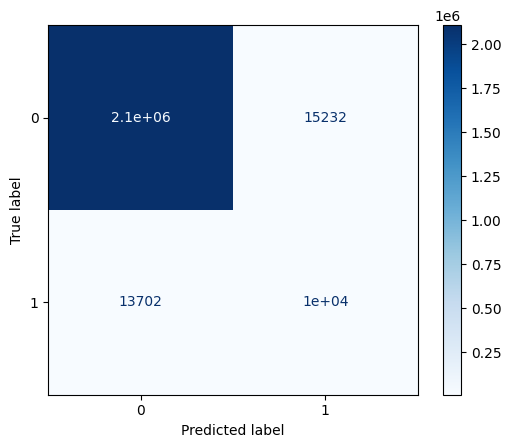

1/1 [==============================] - 0s 97ms/step


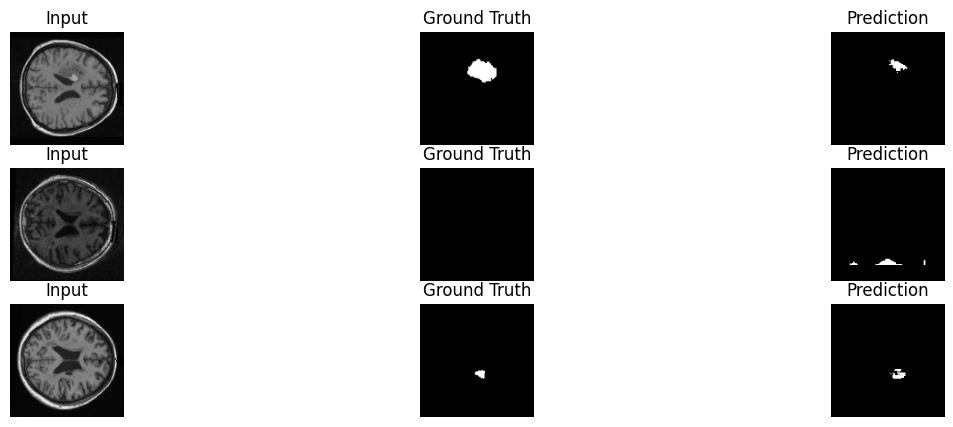

In [69]:
import os
import glob
import numpy as np
import nibabel as nib
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, jaccard_score, accuracy_score
import matplotlib.pyplot as plt

# Function to load NIfTI image based on filename pattern
def load_nifti_image(subject_dir, filename_pattern):
    file_list = glob.glob(os.path.join(subject_dir, filename_pattern))
    if len(file_list) == 0:
        raise FileNotFoundError(f"No files found matching {filename_pattern} in {subject_dir}")
    img = nib.load(file_list[0])
    return img.get_fdata()

# Preprocess image function for U-Net input
def preprocess_image(image_data, target_size=(128, 128)):
    image_data = (image_data - np.min(image_data)) / (np.max(image_data) - np.min(image_data) + 1e-8)
    middle_slice = image_data[:, :, image_data.shape[2] // 2]
    return tf.image.resize(middle_slice[..., np.newaxis], target_size)

# Prepare MRI images and lesion masks for U-Net segmentation
def prepare_data(data_dir, target_size=(128, 128)):
    images = []
    masks = []

    r0_dirs = glob.glob(os.path.join(data_dir, 'R0*/sub-*/ses-1/anat'))
    
    for img_dir in r0_dirs:
        try:
            # Load and preprocess T1-weighted image
            img_data = load_nifti_image(img_dir, 'sub-*_T1w.nii.gz')
            img_preprocessed = preprocess_image(img_data, target_size=target_size)
            images.append(img_preprocessed.numpy())
            
            # Load and preprocess lesion mask
            lesion_mask_data = load_nifti_image(img_dir, 'sub-*_label-L_desc-T1lesion_mask.nii.gz')
            mask_preprocessed = preprocess_image(lesion_mask_data, target_size=target_size)
            masks.append(mask_preprocessed.numpy())
        
        except FileNotFoundError:
            continue

    return np.array(images), np.array(masks)

# Augment data
def augment_data(X, y):
    datagen = ImageDataGenerator(
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.2,
        horizontal_flip=True,
        vertical_flip=True
    )
    aug_X, aug_y = [], []
    for i in range(len(X)):
        it = datagen.flow(X[i:i+1], y[i:i+1], batch_size=1)
        for _ in range(3):  # Generate 3 augmentations per image
            aug_img, aug_mask = next(it)
            aug_X.append(aug_img[0])
            aug_y.append(aug_mask[0])
    return np.array(aug_X), np.array(aug_y)

# Custom loss function
def dice_loss(y_true, y_pred):
    smooth = 1e-5
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def combined_loss(y_true, y_pred):
    return 0.5 * tf.keras.losses.binary_crossentropy(y_true, y_pred) + 0.5 * dice_loss(y_true, y_pred)

# Define U-Net model for lesion segmentation
def unet_model(input_shape=(128, 128, 1)):
    inputs = layers.Input(input_shape)

    # Encoder
    conv1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    conv1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(conv1)
    pool1 = layers.MaxPooling2D((2, 2))(conv1)

    conv2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(conv2)
    pool2 = layers.MaxPooling2D((2, 2))(conv2)

    # Bottleneck
    conv3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = layers.Dropout(0.5)(conv3)
    conv3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(conv3)

    # Decoder
    up1 = layers.Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same')(conv3)
    up1 = layers.concatenate([up1, conv2])
    conv4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(up1)
    conv4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(conv4)

    up2 = layers.Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same')(conv4)
    up2 = layers.concatenate([up2, conv1])
    conv5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(up2)
    conv5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(conv5)

    # Output layer
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(conv5)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss=combined_loss, metrics=['accuracy'])
    return model

# Load training data
data_dir_train = '/Users/olayinkaajao/Downloads/ATLAS_2/Training'
X, y = prepare_data(data_dir_train)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Augment training data
X_train_aug, y_train_aug = augment_data(X_train, y_train)

# Initialize and train the U-Net model
unet = unet_model()
early_stopping = EarlyStopping(monitor='val_loss', patience=5, mode='min', verbose=1, restore_best_weights=True)
unet.fit(X_train_aug, y_train_aug, epochs=40, validation_data=(X_val, y_val), callbacks=[early_stopping])

# Predict on the validation set
y_pred = unet.predict(X_val)

# Threshold predictions to get binary outputs
y_pred_binary = (y_pred > 0.5).astype(np.uint8)
y_val_binary = (y_val > 0.5).astype(np.uint8)

# Calculate Metrics
def calculate_metrics(y_true_binary, y_pred_binary):
    y_true_flat = y_true_binary.flatten()
    y_pred_flat = y_pred_binary.flatten()
    metrics = {
        'Accuracy': accuracy_score(y_true_flat, y_pred_flat),
        'Precision': precision_score(y_true_flat, y_pred_flat),
        'Recall': recall_score(y_true_flat, y_pred_flat),
        'Dice Coefficient': f1_score(y_true_flat, y_pred_flat),
        'Jaccard Index': jaccard_score(y_true_flat, y_pred_flat)
    }
    return metrics

metrics = calculate_metrics(y_val_binary, y_pred_binary)
print("Validation Metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

# Confusion Matrix
def plot_confusion_matrix(y_true_binary, y_pred_binary):
    y_true_flat = y_true_binary.flatten()
    y_pred_flat = y_pred_binary.flatten()
    cm = confusion_matrix(y_true_flat, y_pred_flat)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap=plt.cm.Blues)
    plt.show()

plot_confusion_matrix(y_val_binary, y_pred_binary)

# Visualize predictions
def visualize_predictions(X, y_true, y_pred):
    plt.figure(figsize=(15, 5))
    for i in range(3):
        plt.subplot(3, 3, i * 3 + 1)
        plt.imshow(X[i].squeeze(), cmap='gray')
        plt.title("Input")
        plt.axis('off')

        plt.subplot(3, 3, i * 3 + 2)
        plt.imshow(y_true[i].squeeze(), cmap='gray')
        plt.title("Ground Truth")
        plt.axis('off')

        plt.subplot(3, 3, i * 3 + 3)
        plt.imshow(y_pred[i].squeeze(), cmap='gray')
        plt.title("Prediction")
        plt.axis('off')
    plt.show()
# Confusion Matrix
def plot_confusion_matrix(y_true_binary, y_pred_binary):
    y_true_flat = y_true_binary.flatten()
    y_pred_flat = y_pred_binary.flatten()
    cm = confusion_matrix(y_true_flat, y_pred_flat)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix for True vs Predicted Mask")
    plt.show()

y_pred_val = (unet.predict(X_val[:3]) > 0.5).astype(np.uint8)
visualize_predictions(X_val[:3], y_val[:3], y_pred_val)
